Q1.

In [7]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import numpy as np

iris = datasets.load_iris()
X_orig = iris.data
y = iris.target

sepal_area = X_orig[:, 0] * X_orig[:, 1]

petal_area = X_orig[:, 2] * X_orig[:, 3]

X_new = np.column_stack((sepal_area, petal_area))

X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.40,
    train_size=0.60,
    random_state=123,
    shuffle=True,
    stratify=y
)

clf = svm.SVC()
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
acc = accuracy_score(y_test, preds)

print(f"accuracy score: {acc}")

accuracy score: 0.95


Q2.

correctly classified 6's: 1378 out of 1387


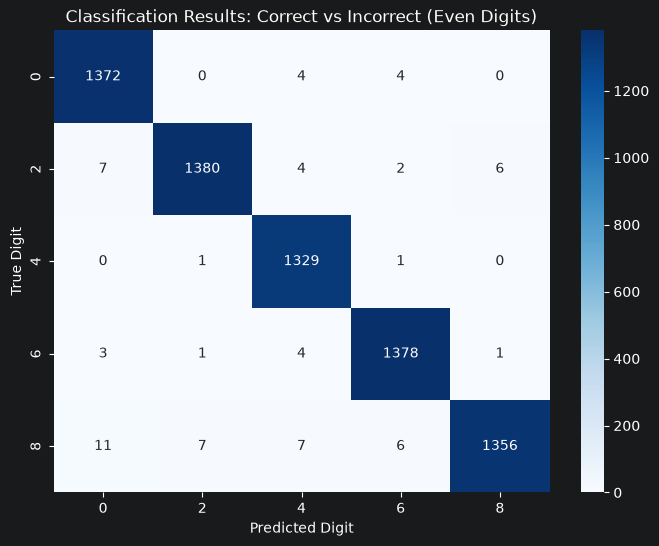

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')
X = mnist.data.values
y = mnist.target.astype(int).values

even_mask = np.isin(y, [0, 2, 4, 6, 8])
X_even = X[even_mask]
y_even = y[even_mask]

X_train, X_test, y_train, y_test = train_test_split(X_even, y_even, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

even_labels = [0, 2, 4, 6, 8]
cm = confusion_matrix(y_test, y_pred, labels=even_labels)

correct_6s = cm[3, 3]
total_6s = np.sum(y_test == 6)
print(f"correctly classified 6's: {correct_6s} out of {total_6s}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=even_labels, yticklabels=even_labels)
plt.title("Classification Results: Correct vs Incorrect (Even Digits)")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

Q3.

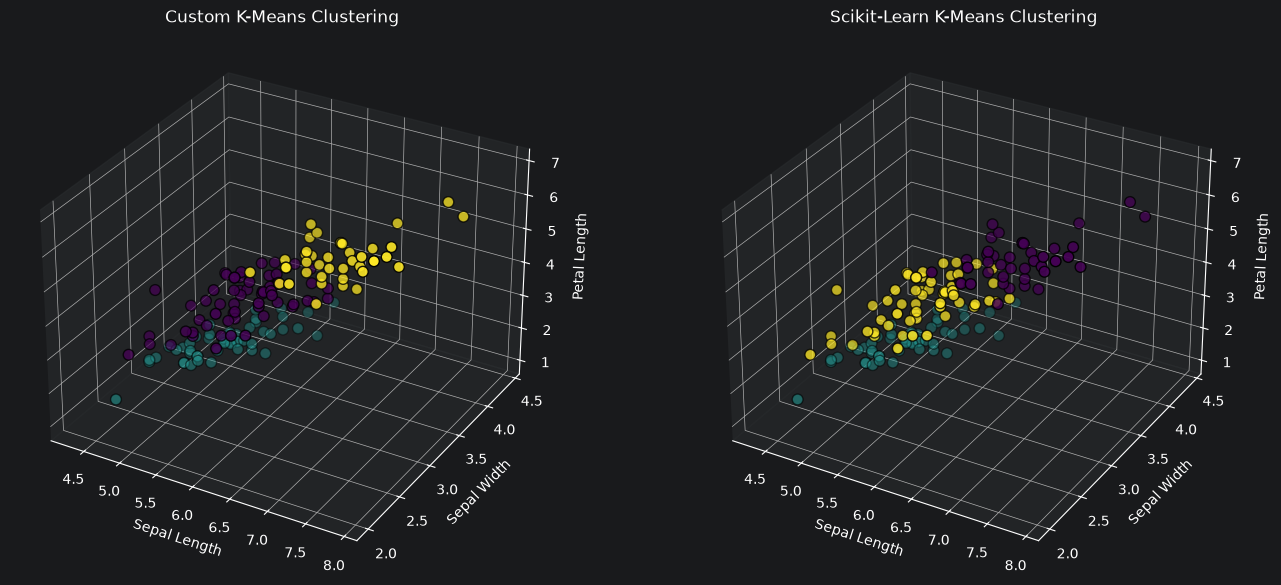

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

class CustomKMeans:
    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def fit_predict(self, X):
        np.random.seed(self.random_state)
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for _ in range(self.max_iters):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.zeros((self.n_clusters, X.shape[1]))
            for i in range(self.n_clusters):
                points = X[self.labels == i]
                if len(points) > 0:
                    new_centroids[i] = points.mean(axis=0)
                else:
                    new_centroids[i] = self.centroids[i]

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        return self.labels

iris = datasets.load_iris()
X = iris.data[:, :3]

custom_kmeans = CustomKMeans(n_clusters=3, random_state=42)
custom_labels = custom_kmeans.fit_predict(X)

sklearn_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sklearn_labels = sklearn_kmeans.fit_predict(X)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=custom_labels, cmap='viridis', edgecolor='k', s=60)
ax1.set_title('Custom K-Means Clustering')
ax1.set_xlabel('Sepal Length')
ax1.set_ylabel('Sepal Width')
ax1.set_zlabel('Petal Length')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=sklearn_labels, cmap='viridis', edgecolor='k', s=60)
ax2.set_title('Scikit-Learn K-Means Clustering')
ax2.set_xlabel('Sepal Length')
ax2.set_ylabel('Sepal Width')
ax2.set_zlabel('Petal Length')

plt.tight_layout()
plt.show()